In [53]:
import pandas as pd
import numpy as np

In [54]:
df = pd.read_csv("../data/spotify_tracks.csv")

In [55]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [56]:
df.shape

(114000, 21)

In [57]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [59]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

Duplicate rows: 0

Missing values:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [60]:
# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows where essential music information is missing
df = df.dropna(subset=["artists", "album_name", "track_name"])

# Reset index after cleaning
df = df.reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (113549, 20)


In [61]:
# Convert duration from milliseconds to minutes
df["duration_min"] = df["duration_ms"] / 60000

# Create a simple mood category based on valence and energy
def classify_mood(row):
    if row["energy"] >= 0.7 and row["valence"] >= 0.6:
        return "Energetic & Happy"
    elif row["energy"] >= 0.7 and row["valence"] < 0.6:
        return "Energetic & Moody"
    elif row["energy"] < 0.7 and row["valence"] >= 0.6:
        return "Calm & Positive"
    else:
        return "Calm & Moody"

df["mood"] = df.apply(classify_mood, axis=1)

df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,mood
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433,Calm & Positive
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500,Calm & Moody
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767,Calm & Moody
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550,Calm & Moody
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217,Calm & Moody


In [62]:
print("Total tracks:", len(df))
print("Total artists:", df["artists"].nunique())
print("Total genres:", df["track_genre"].nunique())

print("\nTop 10 genres:")
print(df["track_genre"].value_counts().head(10))

print("\nTop 10 artists by number of tracks:")
print(df["artists"].value_counts().head(10))

print("\nMost popular tracks:")
print(
    df[["track_name", "artists", "popularity"]]
    .sort_values("popularity", ascending=False)
    .head(10)
)

Total tracks: 113549
Total artists: 31437
Total genres: 114

Top 10 genres:
track_genre
acoustic      1000
british       1000
country       1000
disco         1000
electronic    1000
emo           1000
funk          1000
garage        1000
indie-pop     1000
industrial    1000
Name: count, dtype: int64

Top 10 artists by number of tracks:
artists
The Beatles        279
George Jones       260
Stevie Wonder      235
Linkin Park        224
Ella Fitzgerald    221
Prateek Kuhad      217
Feid               201
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

Most popular tracks:
                                  track_name                  artists  \
19904              Unholy (feat. Kim Petras)     Sam Smith;Kim Petras   
80726              Unholy (feat. Kim Petras)     Sam Smith;Kim Petras   
51449  Quevedo: Bzrp Music Sessions, Vol. 52         Bizarrap;Quevedo   
80884                        I'm Good (Blue)  David Guetta;Bebe Rexha   
29858   

In [63]:
audio_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

correlation_matrix = df[audio_features].corr()

correlation_matrix

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
popularity,1.000000,0.034407,-0.002447,0.047368,-0.045463,-0.022356,-0.094718,-0.005668,-0.041097,0.012187
danceability,0.034407,1.000000,0.131694,0.256559,0.108236,-0.169181,-0.183974,-0.131651,0.476755,-0.051517
energy,-0.002447,0.131694,1.000000,0.760624,0.141976,-0.732747,-0.179967,0.184810,0.258451,0.247361
loudness,0.047368,0.256559,0.760624,1.000000,0.060088,-0.588111,-0.432109,0.076792,0.279428,0.212181
speechiness,-0.045463,0.108236,0.141976,0.060088,1.000000,-0.001378,-0.089214,0.205092,0.036393,0.017167
acousticness,-0.022356,-0.169181,-0.732747,-0.588111,-0.001378,1.000000,0.102134,-0.020313,-0.106240,-0.207620
instrumentalness,-0.094718,-0.183974,-0.179967,-0.432109,-0.089214,0.102134,1.000000,-0.079847,-0.324314,-0.049939
liveness,-0.005668,-0.131651,0.184810,0.076792,0.205092,-0.020313,-0.079847,1.000000,0.019339,0.000547
valence,-0.041097,0.476755,0.258451,0.279428,0.036393,-0.106240,-0.324314,0.019339,1.000000,0.077640
tempo,0.012187,-0.051517,0.247361,0.212181,0.017167,-0.207620,-0.049939,0.000547,0.077640,1.000000


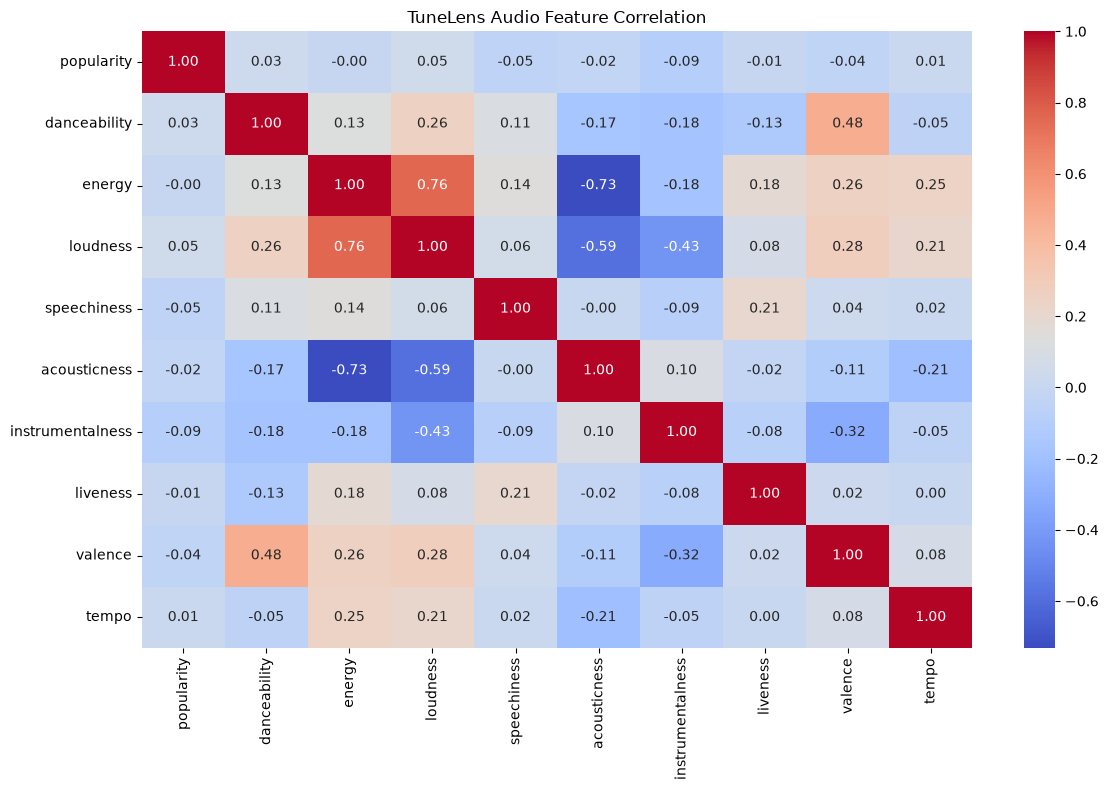

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("TuneLens Audio Feature Correlation")
plt.tight_layout()
plt.show()

In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

In [66]:
recommendation_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

recommendation_data = df[recommendation_features].copy()

scaler = StandardScaler()
feature_matrix = scaler.fit_transform(recommendation_data)

In [67]:
def recommend_songs(track_name, n=5):
    matches = df[
        df["track_name"].str.lower() == track_name.lower()
    ]

    if matches.empty:
        return "Track not found."

    track_index = matches.index[0]

    similarity_scores = cosine_similarity(
        feature_matrix[track_index].reshape(1, -1),
        feature_matrix
    )[0]

    similar_indices = similarity_scores.argsort()[::-1]

    recommendations = []

    for index in similar_indices:
        if index != track_index:
            recommendations.append(index)

        if len(recommendations) == n:
            break

    return df.loc[
        recommendations,
        ["track_name", "artists", "track_genre", "popularity"]
    ]

In [68]:
recommend_songs("Blinding Lights")

,track_name,artists,track_genre,popularity
33437,Atrakce,PAWLIE POIZN;Medooza,emo,36
100111,Me Voy,Los Victorios,ska,34
38383,Mob Rule,Bad//Dreems,garage,29
111616,Benmişim,Nev,turkish,49
19766,My Person,Spencer Crandall,country,61


In [69]:
recommend_songs("Perfect")

,track_name,artists,track_genre,popularity
44956,Perfect,Acoustic Guitar Collective,guitar,39
45704,Ao Clarear,Dieter Huber,guitar,44
45518,Samba Triste,Baden Powell,guitar,24
45608,Anjuli,Hapa,guitar,21
45701,Satellites,Liam Stoler,guitar,46


In [70]:
df["track_name"].head(20)

0                               Comedy
1                     Ghost - Acoustic
2                       To Begin Again
3           Can't Help Falling In Love
4                              Hold On
5                 Days I Will Remember
6                        Say Something
7                            I'm Yours
8                                Lucky
9                               Hunger
10                Give Me Your Forever
11                     I Won't Give Up
12                                Solo
13                            Bad Liar
14                     Hold On - Remix
15    Falling in Love at a Coffee Shop
16               ily (i love you baby)
17                         At My Worst
18                               Lucky
19                          Photograph
Name: track_name, dtype: str

In [71]:
recommend_songs("Shape of You")

,track_name,artists,track_genre,popularity
7395,Reno Ride,Clarence White,bluegrass,24
7806,Always Will,Steve Martin;Steep Canyon Rangers,bluegrass,22
16671,"Minuet in F, K.1d",Wolfgang Amadeus Mozart;Erik Smith,classical,3
76419,Les Indes Galantes - Air pour les esclaves afr...,Jean-Philippe Rameau;Jordi Savall;Le Concert D...,opera,21
38935,"Brandenburg Concerto No. 3 in G, BWV 1048: 1. ...",Johann Sebastian Bach;Berliner Philharmoniker;...,german,0
